In [1]:
import os
os.chdir('/home/jupyter-nafisha/normal-abnormal-multitask/main')

In [2]:
import torch
import pandas as pd
from dataset import XrayDataset
from multimodel import Multimodel
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve
from transformers import AutoModel, AutoProcessor, AutoConfig

/home/jupyter-nafisha/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
MODEL_NAME = "StanfordAIMI/XraySigLIP__vit-l-16-siglip-384__webli"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)
vision_full = AutoModel.from_pretrained(
    MODEL_NAME,
    config=config,
    trust_remote_code=True
).to(device, dtype)
vision_encoder = vision_full.vision_model
del vision_full

/home/jupyter-nafisha/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
checkpoint_path= '/home/jupyter-nafisha/normal-abnormal-multitask/main/best_model_chexpert_balanced.pth'

# img_dir = '/home/common/data_v3'
img_dir = ''
test_csv = '/home/jupyter-nafisha/normal-abnormal-multitask/CSVs/trainWithTBOnlyAbnormalwithBB.csv'

In [5]:
model = Multimodel(vision_encoder = vision_encoder).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

Multimodel(
  (vision_encoder): SiglipVisionTransformer(
    (embeddings): SiglipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16), padding=valid)
      (position_embedding): Embedding(1024, 1024)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-23): 24 x SiglipEncoderLayer(
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024

In [6]:
test_dataset = XrayDataset(img_dir, test_csv, transform=None)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4
)

In [7]:
for image_paths, images, _, label, bbox, _l in test_loader:
    print(bbox)
    break  

tensor([[0.5584, 0.2837, 0.6784, 0.4211]])


In [ ]:
image_names = test_dataset.df["image_id"].tolist()

In [8]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import cv2

def register_pooling_hook(model):
    attn_store = {}

    def pool_hook(module, input, output):
        attn_store["weights"] = output[1]  # [B, 1, 1024]

    model.vision_encoder.head.attention.register_forward_hook(pool_hook)
    return attn_store

def generate_heatmap(pixel_values, attn_weights, img_size=512):
    """
    Returns a numpy image for Gradio
    """

    attn = attn_weights[0, 0]        # [N]
    attn = attn / (attn.max() + 1e-8)

    heatmap = attn.reshape(32, 32)

    heatmap_up = F.interpolate(
        heatmap.unsqueeze(0).unsqueeze(0),
        size=(img_size, img_size),
        mode="bilinear",
        align_corners=False
    )[0, 0]

    heatmap_np = heatmap_up.cpu().numpy()
    heatmap_np = (heatmap_np * 255).astype(np.uint8)

    heatmap_color = cv2.applyColorMap(heatmap_np, cv2.COLORMAP_JET)

    img = pixel_values[0].permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)

    overlay = cv2.addWeighted(img, 0.75, heatmap_color, 0.25, 0)

    return overlay 

In [9]:
def plot_bboxes_from_csv(image_path, csv_data):

    if isinstance(csv_data, str):
        df = pd.read_csv(csv_data)
    else:
        df = csv_data

    rows = df[df['image_id'] == image_path]

    if len(rows) == 0:
        print("No bounding boxes found for:", image_path)
        return None

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for _, row in rows.iterrows():

        x_min = int(row['x_min'])
        y_min = int(row['y_min'])
        x_max = int(row['x_max'])
        y_max = int(row['y_max'])

        cv2.rectangle(
            img,
            (x_min, y_min),
            (x_max, y_max),
            (255, 0, 0),
            8
        )

    return img

In [10]:
def plot_bbox(image_tensor, bbox_tensor):
    img = image_tensor[0].permute(1, 2, 0).cpu().numpy()

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * 255).astype(np.uint8)

    h, w = img.shape[:2]

    x_min, y_min, x_max, y_max = bbox_tensor[0].cpu().numpy()

    x_min = int(x_min * w)
    x_max = int(x_max * w)
    y_min = int(y_min * h)
    y_max = int(y_max * h)

    img_box = img.copy()

    cv2.rectangle(
        img_box,
        (x_min, y_min),
        (x_max, y_max),
        (0, 255, 0),
        2
    )

    return img_box

In [11]:
import matplotlib.pyplot as plt

In [12]:
attention = register_pooling_hook(model)

In [13]:
import pandas as pd
bbox_csv = '/home/jupyter-nafisha/normal-abnormal-multitask/CSVs/trainWithTBOnlyAbnormalwithBB.csv'
BBdata= pd.read_csv(bbox_csv)

In [14]:
BBdata[BBdata['image_id']=='/home/jupyter-nafisha/Data/data_v3_CLAHE/vinbig/ac74ec4ce879ddfe2cb00be038821457.jpg']

,image_id,sex,orientation,x_min,y_min,x_max,y_max,class_name,label
0,/home/jupyter-nafisha/Data/data_v3_CLAHE/vinbi...,M,PA,1615.0,884.0,1962.0,1312.0,Aortic enlargement,Abnormal
3016,/home/jupyter-nafisha/Data/data_v3_CLAHE/vinbi...,M,PA,1390.0,508.0,1750.0,966.0,Lung Opacity,Abnormal


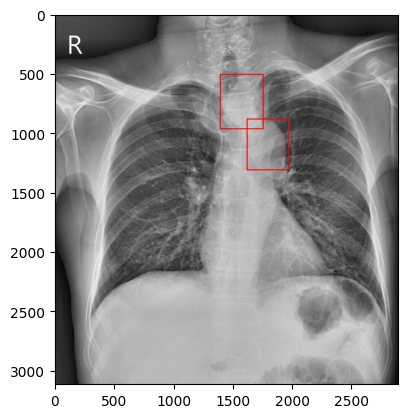

In [15]:
bbox_img = plot_bboxes_from_csv(
    '/home/jupyter-nafisha/Data/data_v3_CLAHE/vinbig/ac74ec4ce879ddfe2cb00be038821457.jpg',
    BBdata
)

plt.imshow(bbox_img)
# plt.axis("off")
# plt.show()

In [18]:
from matplotlib.backends.backend_pdf import PdfPages

predictions = []
true_labels = []
# image_names = []
probabilities = []

pdf_path = '/home/jupyter-nafisha/normal-abnormal-multitask/chexpert-multitask-plottings.pdf'
count =0 

with PdfPages(pdf_path) as pdf:

    with torch.no_grad():
        for image_paths, images, _, labels, bbox, _ in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            pred = int(preds.item())
            true = int(labels.item())

            # if pred == 1 and true == 1:

            heatmap_img = generate_heatmap(images, attention["weights"])
            bbox_img = plot_bboxes_from_csv(image_paths[0], BBdata)
            bbox_img2= plot_bbox(images, bbox)

            fig = plt.figure(figsize=(18, 5))   # wider for 3 panels

            plt.subplot(1, 3, 1)
            plt.imshow(heatmap_img)
            plt.title("Attention Heatmap")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(bbox_img)
            plt.title("CSV Bounding Boxes")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(bbox_img2)
            plt.title("Dataset Bounding Box")
            plt.axis("off")

            plt.tight_layout()

            pdf.savefig(fig)  
            plt.close(fig)  
            count+=1
            if (count%100==0):
                break

In [ ]:
probabilities